In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Manual Fourier transform / inverse Fourier transform


def FT(psi, x, k):
    dx = x[1] - x[0]
    return dx / np.sqrt(2*np.pi) * (
        np.exp(-1j * k[:, None] * x[None, :]) @ psi
    )


def IFT(psi_k, x, k):
    dk = 2*np.pi / (len(x) * (x[1] - x[0]))
    return dk / np.sqrt(2*np.pi) * (
        np.exp(1j * x[:, None] * k[None, :]) @ psi_k
    )



# Gaussian wave packet


def gaussian(x, x0, sigma, p0):
    psi = np.exp(
        -(x-x0)**2 / (4*sigma**2)
        + 1j*p0*x
    )

    dx = x[1] - x[0]
    psi /= np.sqrt(np.sum(np.abs(psi)**2) * dx)

    return psi



# One split-step Fourier step


def split_step(psi, V, k, dt):

    psi *= np.exp(-1j * V * dt/2)

    psi_k = np.fft.fft(psi)
    psi_k *= np.exp(-1j * k**2 * dt/2)

    psi = np.fft.ifft(psi_k)

    psi *= np.exp(-1j * V * dt/2)

    return psi

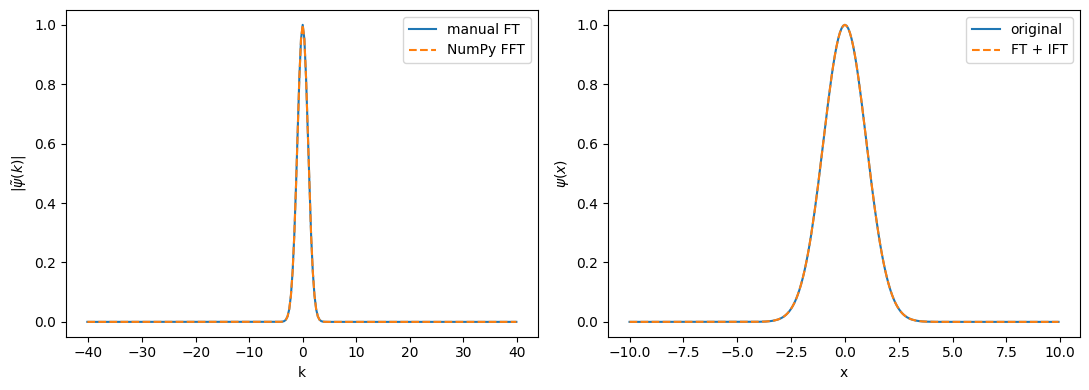

Reconstruction error = 7.153872405668548e-16


In [ ]:

# Exercise 1
=

L = 20
N = 256

dx = L / N
x = np.arange(-L/2, L/2, dx)

k = 2*np.pi*np.fft.fftfreq(N, d=dx)


# Test with Gaussian
psi = np.exp(-x**2 / 2)

# Manual FT
psi_k_manual = FT(psi, x, k)

# NumPy FFT
psi_k_fft = (
    dx / np.sqrt(2*np.pi)
    * np.exp(1j*k*L/2)
    * np.fft.fft(psi)
)

# Inverse manual FT
psi_back = IFT(psi_k_manual, x, k)


fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Fourier transform
ax[0].plot(
    np.fft.fftshift(k),
    np.fft.fftshift(np.abs(psi_k_manual)),
    label="manual FT"
)

ax[0].plot(
    np.fft.fftshift(k),
    np.fft.fftshift(np.abs(psi_k_fft)),
    "--",
    label="NumPy FFT"
)

ax[0].set_xlabel("k")
ax[0].set_ylabel(r"$|\tilde{\psi}(k)|$")
ax[0].legend()


# Original vs inverse FT
ax[1].plot(x, psi, label="original")
ax[1].plot(x, psi_back.real, "--", label="FT + IFT")

ax[1].set_xlabel("x")
ax[1].set_ylabel(r"$\psi(x)$")
ax[1].legend()

plt.tight_layout()
plt.show()

print("Reconstruction error =",
      np.max(np.abs(psi - psi_back)))

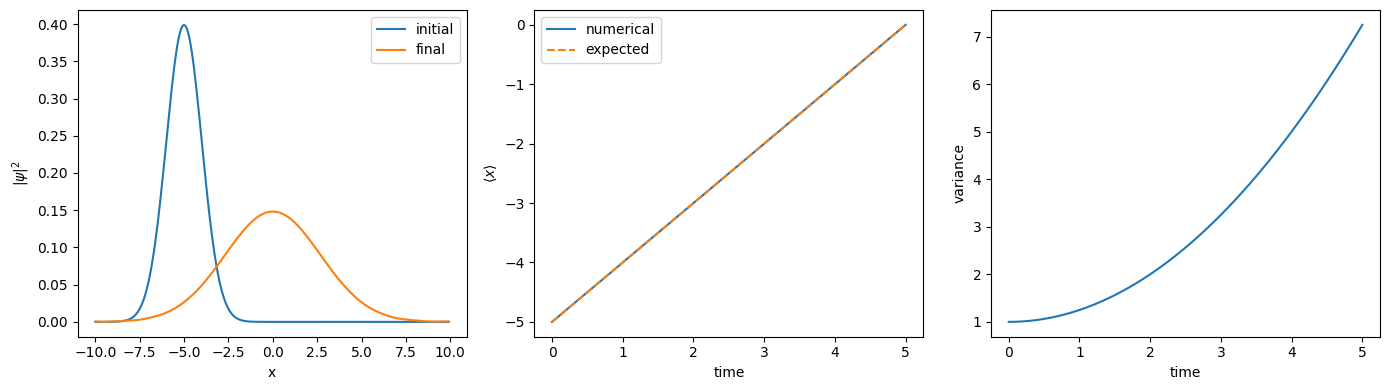

In [ ]:

# Exercise 2


L = 20
N = 256

dx = L / N
x = np.arange(-L/2, L/2, dx)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

x0 = -5
sigma = 1
p0 = 1

dt = 0.1
tsteps = 50

V = np.zeros_like(x)

psi = gaussian(x, x0, sigma, p0)

times = np.arange(tsteps + 1) * dt

mean = []
variance = []

psi_initial = psi.copy()


for n in range(tsteps + 1):

    prob = np.abs(psi)**2

    xm = np.sum(x * prob) * dx

    var = np.sum(
        (x-xm)**2 * prob
    ) * dx

    mean.append(xm)
    variance.append(var)

    if n < tsteps:
        psi = split_step(psi, V, k, dt)


fig, ax = plt.subplots(1, 3, figsize=(14, 4))


# Initial/final packet
ax[0].plot(x, np.abs(psi_initial)**2, label="initial")
ax[0].plot(x, np.abs(psi)**2, label="final")

ax[0].set_xlabel("x")
ax[0].set_ylabel(r"$|\psi|^2$")
ax[0].legend()


# Mean position
ax[1].plot(times, mean, label="numerical")
ax[1].plot(times, x0 + p0*times, "--", label="expected")

ax[1].set_xlabel("time")
ax[1].set_ylabel(r"$\langle x\rangle$")
ax[1].legend()


# Variance
ax[2].plot(times, variance)

ax[2].set_xlabel("time")
ax[2].set_ylabel("variance")


plt.tight_layout()
plt.show()

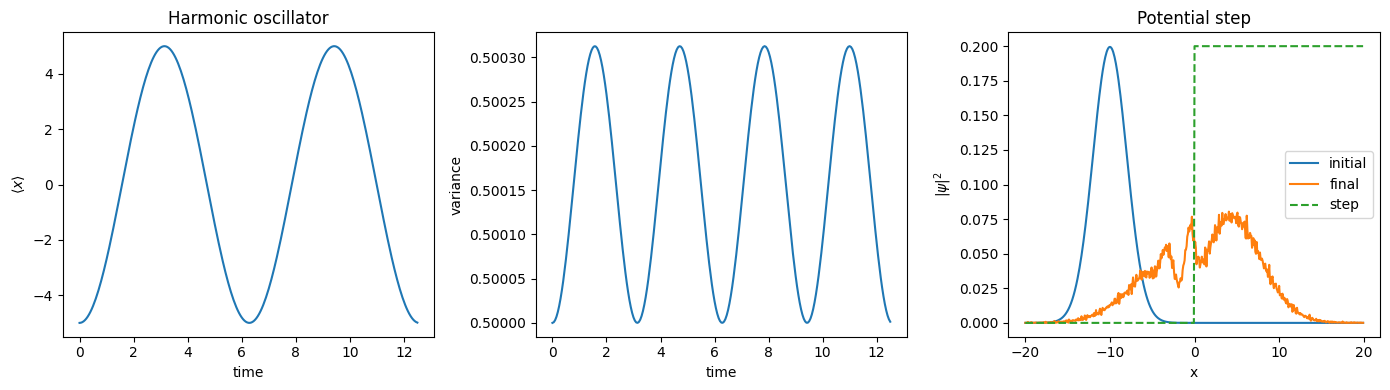

In [ ]:

# Exercise 3


L = 40
N = 512

dx = L / N
x = np.arange(-L/2, L/2, dx)
k = 2*np.pi*np.fft.fftfreq(N, d=dx)

dt = 0.05
tsteps = 250



# A) Harmonic potential


x0 = -5
sigma = 1 / np.sqrt(2)
p0 = 0

V_harm = 0.5 * x**2

psi = gaussian(x, x0, sigma, p0)

mean_harm = []
var_harm = []


for n in range(tsteps + 1):

    prob = np.abs(psi)**2

    xm = np.sum(x * prob) * dx

    mean_harm.append(xm)

    var_harm.append(
        np.sum((x-xm)**2 * prob) * dx
    )

    if n < tsteps:
        psi = split_step(
            psi, V_harm, k, dt
        )



# B) Potential step


x0 = -10
sigma = 2
p0 = 1.5

V0 = 1.0

V_step = np.where(
    x >= 0,
    V0,
    0
)

psi = gaussian(x, x0, sigma, p0)

psi_initial = psi.copy()


for n in range(tsteps):
    psi = split_step(
        psi,
        V_step,
        k,
        dt
    )

psi_final = psi.copy()



# Plots


times = np.arange(tsteps + 1) * dt

fig, ax = plt.subplots(1, 3, figsize=(14, 4))


# Harmonic mean
ax[0].plot(times, mean_harm)

ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$\langle x\rangle$")
ax[0].set_title("Harmonic oscillator")


# Harmonic variance
ax[1].plot(times, var_harm)

ax[1].set_xlabel("time")
ax[1].set_ylabel("variance")


# Step scattering
ax[2].plot(
    x,
    np.abs(psi_initial)**2,
    label="initial"
)

ax[2].plot(
    x,
    np.abs(psi_final)**2,
    label="final"
)

ax[2].plot(
    x,
    0.2 * V_step,
    "--",
    label="step"
)

ax[2].set_xlabel("x")
ax[2].set_ylabel(r"$|\psi|^2$")
ax[2].set_title("Potential step")
ax[2].legend()


plt.tight_layout()
plt.show()